In [2]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# enables responsiveness
%matplotlib widget


In [3]:
# generate data
x = np.arange(0, 10)
y = np.arange(0, 12)
X, Y = np.meshgrid(x, y)
Z = np.sin(0.5 * X) + np.cos(0.5 * Y)
print(X)
print(Y)
print(Z)


[[0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]
 [0 1 2 3 4 5 6 7 8 9]]
[[ 0  0  0  0  0  0  0  0  0  0]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 2  2  2  2  2  2  2  2  2  2]
 [ 3  3  3  3  3  3  3  3  3  3]
 [ 4  4  4  4  4  4  4  4  4  4]
 [ 5  5  5  5  5  5  5  5  5  5]
 [ 6  6  6  6  6  6  6  6  6  6]
 [ 7  7  7  7  7  7  7  7  7  7]
 [ 8  8  8  8  8  8  8  8  8  8]
 [ 9  9  9  9  9  9  9  9  9  9]
 [10 10 10 10 10 10 10 10 10 10]
 [11 11 11 11 11 11 11 11 11 11]]
[[ 1.          1.47942554  1.84147098  1.99749499  1.90929743  1.59847214
   1.14112001  0.64921677  0.2431975   0.02246988]
 [ 0.87758256  1.3570081   1.71905355  1.87507755  1.78687999  1.47605471
   1.01870257  0.52679933  0.12078007 -0.09994756]
 [ 0.54030231  1.01972784  1.38177329  1.53779729  1.44959973  1.13877445
  

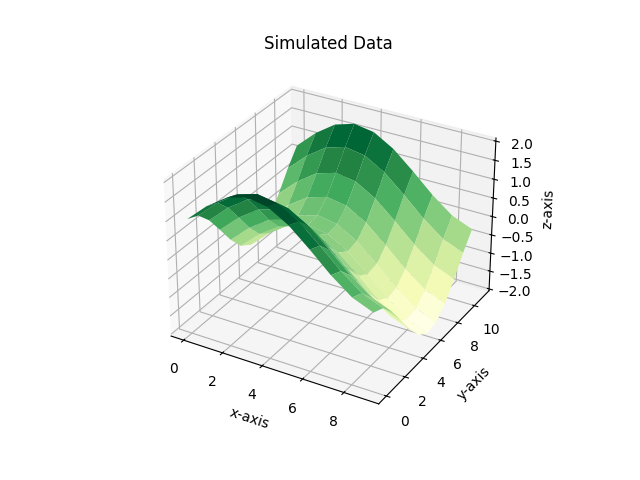

In [4]:
# close any figure if you're rerunning the cell
plt.close()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='YlGn')

# set title and labels 
ax.set_title('Simulated Data')
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')

# displaying the plot 
plt.show()


In [5]:
# load data
diamonds = sns.load_dataset('diamonds')

# train test split the data
X_train, X_test, y_train, y_test = train_test_split(diamonds[['carat', 'depth']], diamonds['price'],
                                                    test_size=0.3, random_state=42)

# train the regressor
rf = RandomForestRegressor()
rf.fit(X_train.to_numpy(), y_train.to_numpy())


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# generate predictions to plot based on field ranges
steps = 50
x_min, x_max = diamonds['carat'].min(), diamonds['carat'].max()
x_steps = (x_max - x_min) / steps
y_min, y_max = diamonds['depth'].min(), diamonds['depth'].max()
y_steps = (y_max - y_min) / steps

x = np.arange(x_min, x_max, x_steps)
y = np.arange(y_min, y_max, y_steps)
X, Y = np.meshgrid(x, y)
XY = np.column_stack([X.ravel(), Y.ravel()])   # (n_samples, 2)
Z = rf.predict(XY).reshape(Y.shape)   # predict and return to meshgrid shape


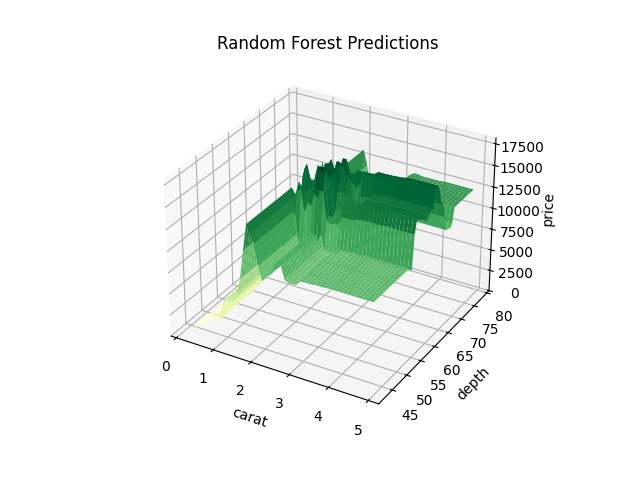

In [7]:
# close any figure if you're rerunning the cell
plt.close()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='YlGn')

# set title and labels 
ax.set_title('Random Forest Predictions')
ax.set_xlabel('carat') 
ax.set_ylabel('depth') 
ax.set_zlabel('price') 

# displaying the plot 
plt.show() 
